# Semana 12 - Practicar Matplotlib

**Propósito:** aplicar `pandas` y `matplotlib` para explorar, graficar e interpretar datos reales de nacimientos y defunciones.

Este notebook está dividido en tres niveles:

- **Nivel básico:** cargar, revisar y limpiar datos.
- **Nivel intermedio:** crear gráficos correctos y explicar lo observado.
- **Reto final:** diseñar un gráfico propio para responder una pregunta.


## Criterios de logro

Al completar la práctica, su entrega debe demostrar que puede:

- Cargar un CSV y revisar su estructura.
- Seleccionar, filtrar y crear columnas nuevas.
- Crear gráficos con título, etiquetas, leyenda y tamaño adecuado.
- Interpretar los gráficos con frases claras.
- Justificar qué tipo de gráfico eligió.


## Nivel básico - 1. Preparación

Ejecute esta celda para cargar las bibliotecas y el archivo de datos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


plt.style.use("seaborn-v0_8-whitegrid")


df = pd.read_csv("nacimientos_defunciones.csv", na_values="NULL", encoding="utf-8", encoding_errors="ignore")


# Convertir la columna 'Nacimientos' a numérica, forzando los errores a NaN
df["Nacimientos"] = df['Nacimientos'].apply(pd.to_numeric, errors='coerce')


print(df.head()) 
print(df.info())  



print("\nValores nulos por columna:")
print(df.isna().sum())  


filtro_nulos = df.isna().any(axis=1)
df[filtro_nulos]


    Año  Nacimientos  Defunciones
0  1950      37248.0       9769.0
1  1950          NaN          NaN
2  1951      39239.0       9631.0
3  1952      42461.0       9902.0
4  1953      42817.0      10312.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Año          75 non-null     int64  
 1   Nacimientos  72 non-null     float64
 2   Defunciones  72 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.9 KB
None

Valores nulos por columna:
Año            0
Nacimientos    3
Defunciones    3
dtype: int64


,Año,Nacimientos,Defunciones
1,1950,NaN,NaN
61,2009,NaN,NaN
74,2022,NaN,NaN


## Nivel básico - 2. Exploración inicial

Complete las instrucciones. La meta es conocer el DataFrame antes de graficar.


In [2]:
# TODO: muestre la cantidad de filas y columnas con df.shape
print("\n👉 Las dimensiones del dataframe son:", df.shape)

# TODO: muestre los nombres de las columnas con df.columns
print("\n👉 Los nombres de las columnas son:", df.columns.tolist())

# TODO: muestre los tipos de datos con df.dtypes
print("\n👉 Los tipos de datos son:", df.dtypes)
# TODO: muestre un resumen estadístico con df.describe()
print("\n👉 Resumen estadístico:")
print("-------------------------")
print(df.describe())


👉 Las dimensiones del dataframe son: (75, 3)

👉 Los nombres de las columnas son: ['Año', 'Nacimientos', 'Defunciones']

👉 Los tipos de datos son: Año              int64
Nacimientos    float64
Defunciones    float64
dtype: object

👉 Resumen estadístico:
-------------------------
               Año   Nacimientos   Defunciones
count    75.000000     72.000000     72.000000
mean   1985.826667  67308.430556  13548.625000
std      21.508875  11303.292169   4872.104426
min    1950.000000  37248.000000   8596.000000
25%    1967.500000  58944.750000   9899.750000
50%    1986.000000  69996.500000  11377.500000
75%    2004.500000  75490.500000  15837.250000
max    2022.000000  84337.000000  31093.000000


**Pregunta de interpretación:** ¿qué años cubre el archivo y cuántos registros tiene?


## Nivel básico - 3. Limpieza básica

Antes de analizar, confirme si hay valores nulos.


In [3]:
# TODO: muestre cuántos valores nulos hay por columna
print("\n👉 Valores nulos por columna:")
print(df.isna().sum())

filtros_nulos = df.isna().any(axis=1)
print("\n👉 Filas con valores nulos:")
print(df[filtros_nulos])

# TODO: elimine filas con valores nulos, si existieran
df.dropna(inplace=True)

# TODO: vuelva a revisar los valores nulos
print("\n👉 Valores nulos por columna después de eliminar filas:")
print(df.isna().sum())



👉 Valores nulos por columna:
Año            0
Nacimientos    3
Defunciones    3
dtype: int64

👉 Filas con valores nulos:
     Año  Nacimientos  Defunciones
1   1950          NaN          NaN
61  2009          NaN          NaN
74  2022          NaN          NaN

👉 Valores nulos por columna después de eliminar filas:
Año            0
Nacimientos    0
Defunciones    0
dtype: int64


**Pista:** puede usar `df.isna().sum()` y `df.dropna(inplace=True)`.


## Nivel básico - 4. Selección de columnas

Cree un DataFrame solo con `Año` y `Nacimientos`.


In [4]:
# TODO: cree un DataFrame llamado df_nacimientos con las columnas Año y Nacimientos
# df_nacimientos = df[["Año", "Nacimientos"]]
df_nacimientos = df.loc[:, ["Año", "Nacimientos"]]

# TODO: muestre las primeras 5 filas
df_nacimientos.head(5) # default 5 si es head() sin argumentos



,Año,Nacimientos
0,1950,37248.0
2,1951,39239.0
3,1952,42461.0
4,1953,42817.0
5,1954,48157.0


**Pregunta de interpretación:** ¿por qué conviene crear DataFrames más pequeños para ciertos análisis?


## Nivel básico - 5. Filtrado de datos

Cree un DataFrame con datos desde 2010 en adelante.


In [9]:
# TODO: cree un DataFrame llamado df_2010 con datos desde el año 2010
df_2010 = df[df['Año'] == 2010]

# TODO: muestre los datos filtrados
df_2010


,Año,Nacimientos,Defunciones
62,2010,70922.0,19077.0


**Pista:** use una condición como `df["Año"] >= 2010`.


## Nivel intermedio - 6. Cálculos básicos

Calcule totales y agregue una columna nueva.


In [14]:
# TODO: calcule el total de nacimientos
total_nacimientos = df["Nacimientos"].sum()

# TODO: calcule el total de defunciones
total_defunciones = df["Defunciones"].sum()

# TODO: cree la columna Saldo Poblacional
df["Saldo Poblacional"] = df["Nacimientos"] - df["Defunciones"]

# TODO: muestre total_nacimientos, total_defunciones y df.head()
print(f"👉 Total de nacimientos: {total_nacimientos:,.0f}")
print(f"👉 Total de defunciones: {total_defunciones:,.0f}")
print("-"*40)
print(f"👉 Saldo Poblacional: {df['Saldo Poblacional'].sum():,.0f}")
df.head()


👉 Total de nacimientos: 4,846,207
👉 Total de defunciones: 975,501
----------------------------------------
👉 Saldo Poblacional: 3,870,706


,Año,Nacimientos,Defunciones,Saldo Poblacional
0,1950,37248.0,9769.0,27479.0
2,1951,39239.0,9631.0,29608.0
3,1952,42461.0,9902.0,32559.0
4,1953,42817.0,10312.0,32505.0
5,1954,48157.0,9713.0,38444.0


**Pregunta de interpretación:** ¿qué significa el saldo poblacional en este conjunto de datos?


## Nivel intermedio - 7. Gráfico de líneas: nacimientos por año

Cree un gráfico de líneas con `Año` en el eje X y `Nacimientos` en el eje Y.


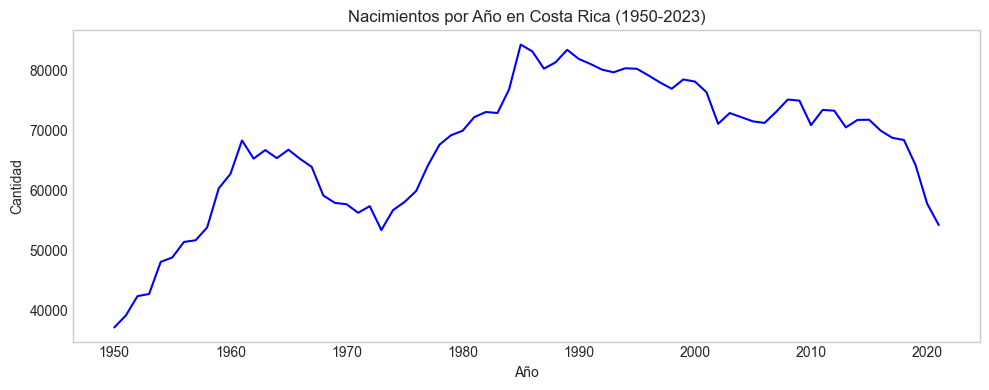

In [25]:
# TODO: cree una figura con figsize=(10, 4)
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)
# TODO: grafique Año vs Nacimientos
ax.plot(df["Año"], df["Nacimientos"],  linestyle="-", color="blue", label="Nacimientos")

# TODO: agregue título, etiqueta X, etiqueta Y y plt.tight_layout()
ax.set_title("Nacimientos por Año en Costa Rica (1950-2023)")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad")

plt.tight_layout()

# TODO: muestre el gráfico con plt.show()
plt.show()


**Pregunta de interpretación:** ¿los nacimientos muestran una tendencia general de aumento, disminución o estabilidad?


## Nivel intermedio - 8. Comparación de nacimientos y defunciones

Cree un gráfico con dos líneas y una leyenda.


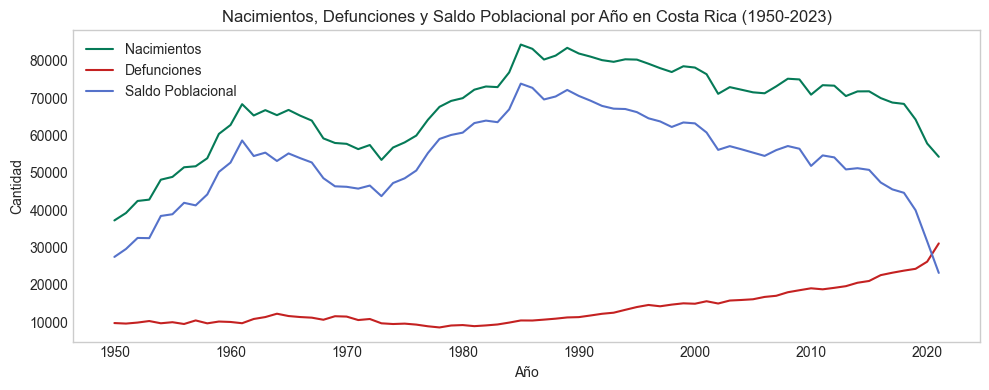

In [28]:
# TODO: cree fig, ax = plt.subplots(figsize=(10, 4))
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)
# TODO: grafique Nacimientos y Defunciones contra Año
ax.plot(df["Año"], df["Nacimientos"], linestyle="-", color="#057A57", label="Nacimientos")
ax.plot(df["Año"], df["Defunciones"], linestyle="-", color="#C42121", label="Defunciones")

ax.plot(df["Año"], df["Saldo Poblacional"], linestyle="-", color="#5572CA", label="Saldo Poblacional")

# TODO: use colores distintos y label en cada línea
# TODO: agregue título, etiquetas y leyenda
ax.set_title("Nacimientos, Defunciones y Saldo Poblacional por Año en Costa Rica (1950-2023)")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad")
ax.legend()

# TODO: aplique plt.tight_layout() y plt.show()
plt.tight_layout()
plt.show()


**Pregunta de interpretación:** ¿en qué parte del periodo la distancia entre nacimientos y defunciones parece mayor?


## Nivel intermedio - 9. Gráfico de barras del último año

Compare nacimientos y defunciones en el último año disponible.


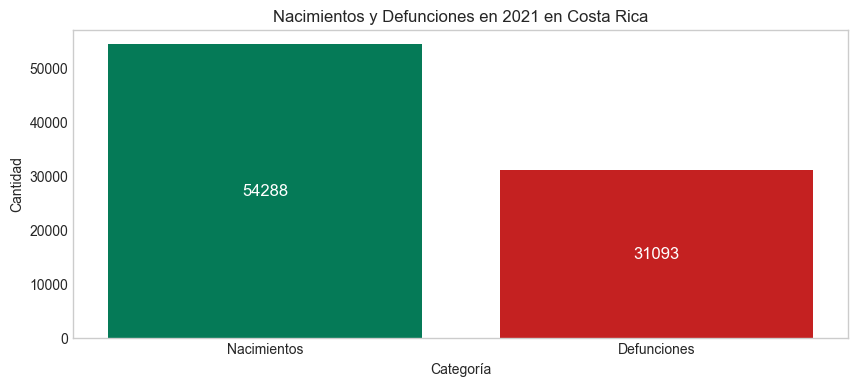

In [48]:
# TODO: cree fig, ax = plt.subplots(figsize=(10, 4))
from matplotlib import axes


fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)

# TODO: obtenga el último año disponible con df["Año"].max()
ultimo_anio = df["Año"].max()

# TODO: filtre la fila del último año
datos_ultimo_anio = df[df["Año"] == ultimo_anio]

# TODO: cree listas para categorias y valores
# categorias = ["Nacimientos", "Defunciones"] en números enteros
valores = [int(datos_ultimo_anio["Nacimientos"].values[0]), int(datos_ultimo_anio["Defunciones"].values[0])]

# TODO: cree un gráfico de barras con título y etiquetas
ax.bar(["Nacimientos", "Defunciones"], valores, color=["#057A57", "#C42121"])
ax.set_title(f"Nacimientos y Defunciones en {ultimo_anio} en Costa Rica")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad")

for x, y in zip(["Nacimientos", "Defunciones"], valores):
    ax.text(x, y / 2, str(y), ha="center", va="center", fontsize=12, color="#ffffff")
    
plt.show()


**Pregunta de interpretación:** ¿qué diferencia observa entre nacimientos y defunciones en el último año?


## Nivel intermedio - 10. Saldo poblacional desde 2010

Use los datos filtrados desde 2010 y grafique el saldo poblacional.


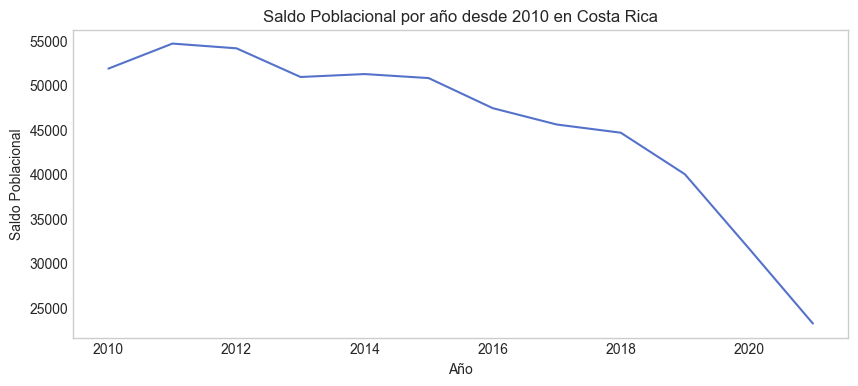

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)

# TODO: asegúrese de que df_2010 tenga una copia de los datos filtrados
filtro_2010 = df["Año"] >= 2010
df_2010 = df[filtro_2010].copy()

# TODO: cree la columna Saldo Poblacional en df_2010
df_2010["Saldo Poblacional"] = df_2010["Nacimientos"] - df_2010["Defunciones"]

# TODO: grafique Año vs Saldo Poblacional
ax.plot(df_2010["Año"], df_2010["Saldo Poblacional"],  linestyle="-", color="#5572CA")
ax.set_title("Saldo Poblacional por año desde 2010 en Costa Rica")
ax.set_xlabel("Año")
ax.set_ylabel("Saldo Poblacional")
plt.show()

**Pregunta de interpretación:** ¿el saldo poblacional desde 2010 sube, baja o se mantiene? Explique con base en el gráfico.


## Nivel intermedio - 11. Subgráficos

Cree una figura con dos subgráficos:

1. Nacimientos y defunciones por año.
2. Saldo poblacional por año.


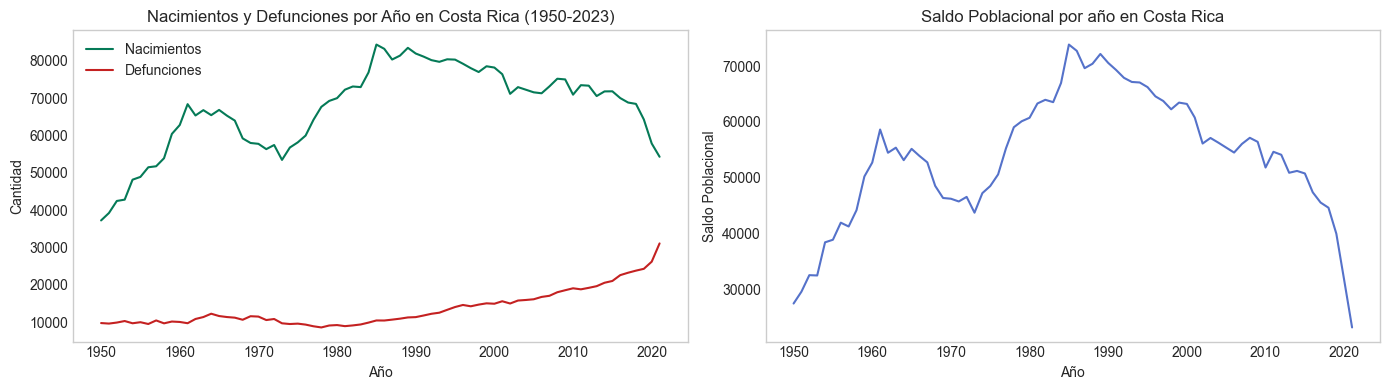

In [52]:
# TODO: cree fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    ax.grid(False)

# TODO: en axes[0], grafique nacimientos y defunciones por año
axes[0].plot(df["Año"], df["Nacimientos"], linestyle="-", color="#057A57", label="Nacimientos")
axes[0].plot(df["Año"], df["Defunciones"], linestyle="-", color="#C42121", label="Defunciones")
axes[0].set_title("Nacimientos y Defunciones por Año en Costa Rica (1950-2023)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Cantidad")
axes[0].legend()

# TODO: en axes[1], grafique saldo poblacional por año
axes[1].plot(df["Año"], df["Saldo Poblacional"], linestyle="-", color="#5572CA")
axes[1].set_title("Saldo Poblacional por año en Costa Rica")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Saldo Poblacional")

# TODO: use plt.tight_layout() y plt.show()
plt.tight_layout()
plt.show()



**Pregunta de interpretación:** ¿qué ventaja tiene ver ambos gráficos en una misma figura?


## Buenas prácticas antes del reto final

Revise que sus gráficos cumplan con estas reglas:

- El título explica el contenido del gráfico.
- Los ejes tienen nombres claros.
- La leyenda aparece cuando hay más de una serie.
- Los colores tienen un propósito.
- El gráfico responde una pregunta concreta.


## Reto final - 12. Pregunta propia

Construya un gráfico propio que responda una pregunta sobre los datos.

Ejemplos:

- ¿Cuáles son los 10 años con más nacimientos?
- ¿Cómo cambió el saldo poblacional en las últimas dos décadas?
- ¿Las defunciones aumentan o disminuyen con el tiempo?
- ¿Qué diferencia hay entre el primer y el último año del registro?


**Pregunta elegida:** escriba aquí la pregunta que desea responder.


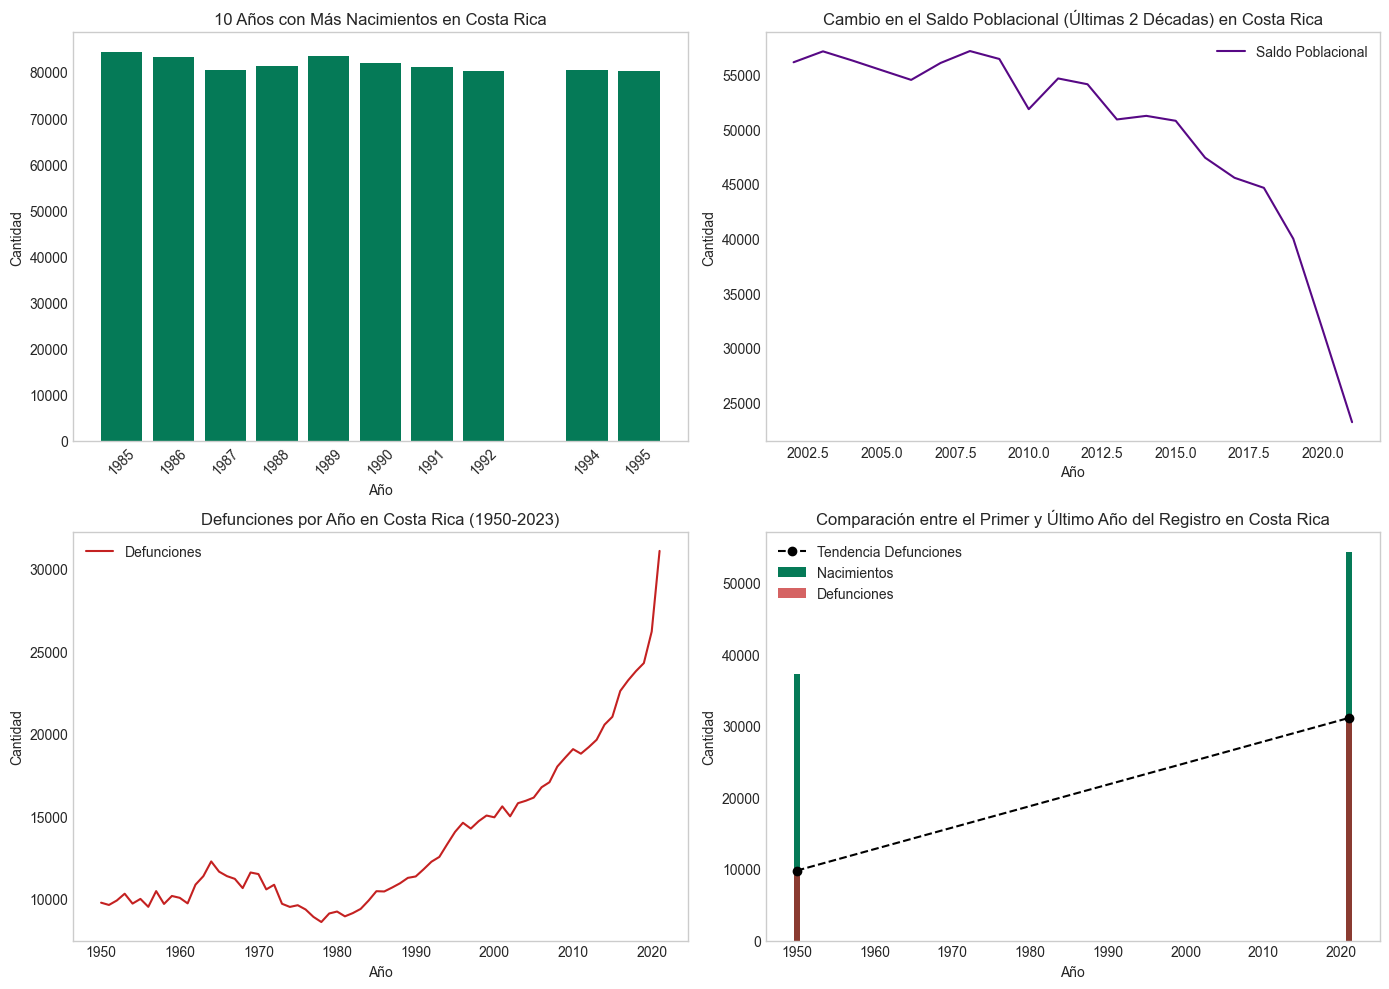

In [ ]:


# TODO: cree fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax in axes.flatten():
    ax.grid(False)

#- ¿Cuáles son los 10 años con más nacimientos?
df_anios_mayor_nacimientos = df.sort_values(by="Nacimientos", ascending=False).head(10)
axes[0, 0].bar(df_anios_mayor_nacimientos["Año"], df_anios_mayor_nacimientos["Nacimientos"], color="#057A57")
axes[0, 0].set_xticks(df_anios_mayor_nacimientos["Año"])
axes[0, 0].set_xticklabels(df_anios_mayor_nacimientos["Año"], rotation=45)
axes[0, 0].set_title("10 Años con Más Nacimientos en Costa Rica")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("Cantidad")

df_anios_mayor_nacimientos = (
  df.sort_values(by="Nacimientos", ascending=False)
      .head(10)
      .sort_values(by="Año")
)

axes[0, 0].tick_params(axis="x", rotation=45)

#- ¿Cómo cambió el saldo poblacional en las últimas dos décadas?
df_ultimas_dos_decadas = df.tail(20)
axes[0, 1].plot(df_ultimas_dos_decadas["Año"], df_ultimas_dos_decadas["Saldo Poblacional"], linestyle="-", color="#570885", label="Saldo Poblacional")
axes[0, 1].set_title("Cambio en el Saldo Poblacional (Últimas 2 Décadas) en Costa Rica")
axes[0, 1].set_xlabel("Año")
axes[0, 1].set_ylabel("Cantidad")
axes[0, 1].legend()

#- ¿Las defunciones aumentan o disminuyen con el tiempo?
df_defunciones_por_año = df.groupby("Año")["Defunciones"].sum().reset_index()
axes[1, 0].plot(df_defunciones_por_año["Año"], df_defunciones_por_año["Defunciones"], linestyle="-", color="#C42121", label="Defunciones")
axes[1, 0].set_title("Defunciones por Año en Costa Rica (1950-2023)")
axes[1, 0].set_xlabel("Año")
axes[1, 0].set_ylabel("Cantidad")
axes[1, 0].legend()

# #- ¿Qué diferencia hay entre el primer y el último año del registro?
df_primer_ultimo_año = df[df["Año"].isin([df["Año"].min(), df["Año"].max()])]
axes[1, 1].bar(df_primer_ultimo_año["Año"], df_primer_ultimo_año["Nacimientos"], color="#057A57", label="Nacimientos")
axes[1, 1].bar(df_primer_ultimo_año["Año"], df_primer_ultimo_año["Defunciones"], color="#C42121", label="Defunciones", alpha=0.7)
# línea de comparación entre primer y último año
axes[1, 1].plot(
    df_primer_ultimo_año["Año"],
    df_primer_ultimo_año["Defunciones"],
    color="black",
    linestyle="--",
    marker="o",
    label="Tendencia Defunciones"
)
axes[1, 1].set_title("Comparación entre el Primer y Último Año del Registro en Costa Rica")
axes[1, 1].set_xlabel("Año")
axes[1, 1].set_ylabel("Cantidad")
axes[1, 1].legend()

plt.tight_layout()
plt.show()



**Interpretación final:** escriba 3 o 4 frases explicando qué muestra su gráfico y qué conclusión obtiene.


## Rúbrica breve

Use esta rúbrica para revisar su entrega:

| Criterio | Logrado | Pendiente |
|---|---|---|
| El notebook ejecuta sin errores |  |  |
| El CSV se carga correctamente |  |  |
| Se crean columnas y filtros solicitados |  |  |
| Los gráficos tienen título y etiquetas |  |  |
| Las interpretaciones responden las preguntas |  |  |
| El reto final tiene una pregunta clara |  |  |


## Cierre metacognitivo

Responda:

1. ¿Qué gráfico le ayudó más a entender los datos?
2. ¿Qué decisión visual cambió más la lectura del gráfico?
3. ¿Qué parte de Matplotlib necesita seguir practicando?
